# 03 Faktor yang Menentukan Nilai Klaim

Overview kompetisi meminta analisis faktor yang paling berpengaruh terhadap nilai klaim, supaya
perusahaan bisa melakukan seleksi risiko, pencegahan, atau deteksi dini.

Pendekatannya: model yang memprediksi nilai satu klaim dari ciri nasabah dan ciri klaimnya, lalu
dijelaskan dengan SHAP untuk melihat faktor mana yang paling mendorong nilai klaim naik atau turun.
Model ini untuk **menjelaskan**, bukan untuk forecasting bulanan.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import klaim

pd.set_option("display.float_format", "{:,.1f}".format)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False})
JUTA = 1e6
import lightgbm as lgb
import shap
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score

D:\KULIAH BINUS\PORTOFOLIO MAGANG\MCF ITB\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
k = klaim.muat_klaim()
p = klaim.muat_polis()
d = k.merge(p, on="Nomor Polis", how="left")

d["usia"] = (d["Tanggal Pasien Masuk RS"] - d["Tanggal Lahir"]).dt.days / 365.25
d["lama_polis_tahun"] = (d["Tanggal Pasien Masuk RS"] - d["Tanggal Efektif Polis"]).dt.days / 365.25
d["lama_rawat_hari"] = (d["Tanggal Pasien Keluar RS"] - d["Tanggal Pasien Masuk RS"]).dt.days
d["bab_icd"] = d["ICD Diagnosis"].str[0].fillna("?")
d["lokasi_rs"] = d["Lokasi RS"].where(d["Lokasi RS"].isin(["Indonesia", "Singapore", "Malaysia"]), "Lainnya")
top_dom = d["Domisili"].value_counts().head(6).index
d["domisili"] = d["Domisili"].where(d["Domisili"].isin(top_dom), "Lainnya")
d["jenis_rawat"] = d["Inpatient/Outpatient"].fillna("?")
d["y"] = np.log1p(d[klaim.NILAI])

FITUR = ["usia", "lama_polis_tahun", "lama_rawat_hari", "Plan Code", "Gender", "domisili",
         "jenis_rawat", "Reimburse/Cashless", "lokasi_rs", "bab_icd"]
KATEGORI = ["Plan Code", "Gender", "domisili", "jenis_rawat", "Reimburse/Cashless", "lokasi_rs", "bab_icd"]
X = d[FITUR].copy()
for c in KATEGORI:
    X[c] = X[c].astype("category")
print(X.shape)

(4627, 10)


Nilai klaim sangat miring (median Rp14 juta, maksimum Rp2,2 miliar), jadi yang diprediksi adalah
logaritmanya. Dengan begitu satu klaim raksasa tidak mendominasi model.

Kode ICD dikelompokkan per huruf pertama (bab ICD-10, misalnya C untuk kanker, I untuk penyakit
peredaran darah), karena ada 753 kode berbeda dan kebanyakan hanya muncul beberapa kali.

## 1. Seberapa baik model menjelaskan nilai klaim

Validasi silang 5-fold dengan **GroupKFold per nomor polis**, supaya klaim dari nasabah yang sama
tidak muncul di data latih dan data uji sekaligus. Pembanding: tebakan rata-rata per jenis perawatan
(rawat inap, rawat jalan, dan seterusnya).

In [3]:
cv = GroupKFold(n_splits=5)
pred_model = np.zeros(len(d))
pred_patokan = np.zeros(len(d))
params = dict(n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=30,
              subsample=0.8, subsample_freq=1, colsample_bytree=0.8, verbose=-1, random_state=42)

for latih, uji in cv.split(X, d["y"], groups=d["Nomor Polis"]):
    m = lgb.LGBMRegressor(**params).fit(X.iloc[latih], d["y"].iloc[latih])
    pred_model[uji] = m.predict(X.iloc[uji])
    rata_per_jenis = d.iloc[latih].groupby("jenis_rawat")["y"].mean()
    pred_patokan[uji] = d["jenis_rawat"].iloc[uji].map(rata_per_jenis).fillna(d["y"].iloc[latih].mean())

print(f"R2 (skala log) patokan rata-rata per jenis perawatan: {r2_score(d['y'], pred_patokan):.3f}")
print(f"R2 (skala log) LightGBM                           : {r2_score(d['y'], pred_model):.3f}")

R2 (skala log) patokan rata-rata per jenis perawatan: 0.148
R2 (skala log) LightGBM                           : 0.504


Model menjelaskan sekitar separuh variasi nilai klaim (R2 0,50), dibanding 0,15 untuk patokan yang
hanya melihat jenis perawatan. Sisanya yang tidak terjelaskan wajar: tingkat keparahan penyakit dan tindakan medis yang
dilakukan tidak ada di data.

## 2. Faktor yang paling berpengaruh

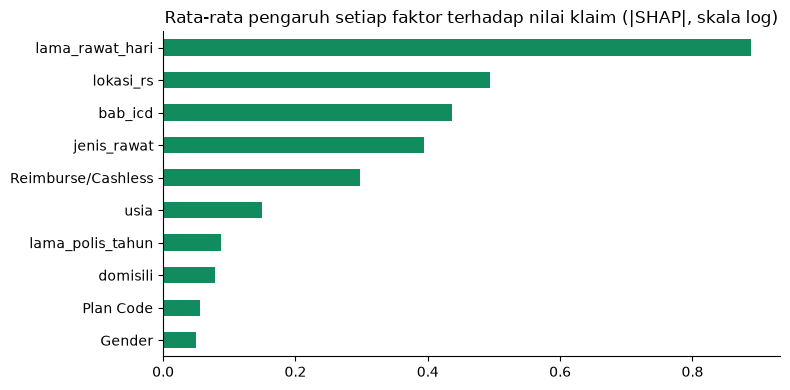

In [4]:
model = lgb.LGBMRegressor(**params).fit(X, d["y"])
nilai_shap = shap.TreeExplainer(model).shap_values(X)
penting = pd.Series(np.abs(nilai_shap).mean(axis=0), index=FITUR).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
penting.plot.barh(ax=ax, color="#128c5e")
ax.set_title("Rata-rata pengaruh setiap faktor terhadap nilai klaim (|SHAP|, skala log)")
plt.tight_layout()
plt.show()

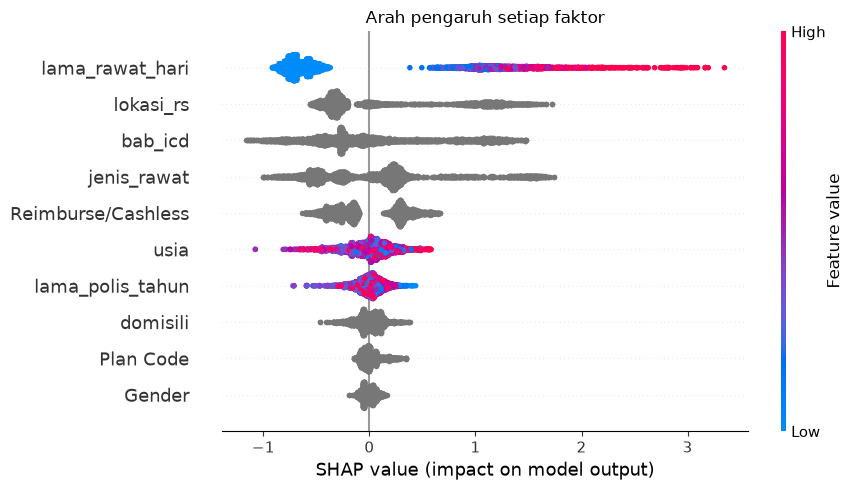

In [5]:
shap.summary_plot(nilai_shap, X, show=False, plot_size=(9, 5))
plt.title("Arah pengaruh setiap faktor")
plt.tight_layout()
plt.show()

## 3. Memeriksa faktor utama dengan angka langsung

SHAP menunjukkan faktor yang dipakai model. Tabel berikut memeriksa faktor-faktor itu langsung dari
data, supaya kesimpulannya tidak hanya bergantung pada model.

In [6]:
median_juta = lambda s: s.median() / JUTA
print("Median nilai klaim (juta Rp) per lama rawat:")
print(d.groupby(pd.cut(d["lama_rawat_hari"], [-1, 0, 2, 5, 10, 1000],
                       labels=["0 hari", "1-2", "3-5", "6-10", ">10"]), observed=True)[klaim.NILAI]
       .agg(["size", median_juta]).rename(columns={"<lambda_0>": "median (juta)"}))
print()
print("Median dan rata-rata nilai klaim (juta Rp) per lokasi RS:")
print(d.groupby("lokasi_rs")[klaim.NILAI].agg(["size", "median", "mean"]).assign(
    median=lambda t: t["median"] / JUTA, mean=lambda t: t["mean"] / JUTA).round(1))
print()
bab = d.groupby("bab_icd")[klaim.NILAI].agg(["size", "sum"]).assign(porsi=lambda t: t["sum"] / t["sum"].sum() * 100)
print("Bab ICD dengan porsi total klaim terbesar (%):")
print(bab.sort_values("porsi", ascending=False).head(6)[["size", "porsi"]].round(1))
print()
print(f"Usia saat klaim: rata-rata {d['usia'].mean():.1f} tahun, median {d['usia'].median():.1f} tahun")

Median nilai klaim (juta Rp) per lama rawat:
                 size  median (juta)
lama_rawat_hari                     
0 hari           3105            2.9
1-2               734           30.9
3-5               482           36.1
6-10              230           67.2
>10                76          198.7

Median dan rata-rata nilai klaim (juta Rp) per lokasi RS:
           size  median  mean
lokasi_rs                    
Indonesia  3102     8.7  33.7
Lainnya      50    35.0 102.9
Malaysia    456    16.8  39.1
Singapore  1019    52.6 124.7

Bab ICD dengan porsi total klaim terbesar (%):
         size  porsi
bab_icd             
C         934   29.6
I         383   16.4
M         372   12.1
K         543    8.8
H         549    5.7
N         713    5.6

Usia saat klaim: rata-rata 59.3 tahun, median 59.9 tahun


In [7]:
# Plan dan lokasi RS saling terkait: porsi klaim per lokasi untuk setiap plan (%)
print((pd.crosstab(d["Plan Code"], d["lokasi_rs"], normalize="index") * 100).round(0))
print()
print("Median nilai klaim rawat inap di Indonesia per plan (juta Rp):")
print((d[(d["lokasi_rs"] == "Indonesia") & (d["jenis_rawat"] == "IP")].groupby("Plan Code")[klaim.NILAI].median() / JUTA).round(1))

lokasi_rs  Indonesia  Lainnya  Malaysia  Singapore
Plan Code                                         
M-001           39.0      1.0      10.0       50.0
M-002           64.0      1.0      13.0       22.0
M-003          100.0      0.0       0.0        0.0

Median nilai klaim rawat inap di Indonesia per plan (juta Rp):
Plan Code
M-001   14.6
M-002   20.4
M-003   29.3
Name: Nominal Klaim Yang Disetujui, dtype: float64


## Kesimpulan dan rekomendasi

Urutan faktor dari SHAP: lama rawat, lokasi RS, bab diagnosis ICD, jenis perawatan, lalu cara klaim
(reimburse atau cashless). Usia, plan, domisili, dan gender pengaruhnya kecil.

1. **Lama rawat adalah penentu terbesar.** Median klaim tanpa menginap Rp2,9 juta, rawat 6 sampai 10
   hari Rp67 juta, dan lebih dari 10 hari Rp199 juta. Pengendalian biaya paling berdampak di kasus rawat
   inap panjang, misalnya peninjauan ulang kasus setelah sejumlah hari tertentu.
2. **Lokasi RS lebih penting daripada jenis plan.** Median klaim di Singapura Rp53 juta, dibanding Rp9 juta
   di Indonesia. Plan dan lokasi saling terkait: semua klaim plan M-003 terjadi di Indonesia, sedangkan
   separuh klaim plan M-001 terjadi di Singapura. Di model, pengaruh plan kecil setelah lokasi RS, lama
   rawat, dan diagnosis ikut dihitung, jadi perbedaan biaya antarplan sebagian besar terjelaskan oleh
   tempat berobat. Plan tetap sedikit berpengaruh: di rawat inap dalam negeri, median klaim plan M-003
   lebih tinggi daripada plan lain. Kerja sama dengan rumah sakit rekanan di dalam negeri untuk kasus
   berat berpotensi menekan biaya.
3. **Tiga kelompok diagnosis menyumbang 58% total klaim:** neoplasma atau kanker (bab C, 30%), penyakit
   jantung dan pembuluh darah (bab I, 16%), serta otot dan tulang (bab M, 12%). Dengan usia rata-rata
   nasabah yang mengajukan klaim sekitar 59 tahun, program skrining dini kanker dan jantung adalah
   kandidat pencegahan yang paling relevan.
4. **Klaim terpusat di sedikit nasabah.** Sepuluh polis menyumbang 18% seluruh klaim (notebook 01),
   sehingga pendampingan untuk nasabah dengan klaim berulang lebih efektif daripada program yang
   menyasar semua nasabah.
## Keterbatasan

- Model menjelaskan hubungan, bukan sebab-akibat. Misalnya, klaim luar negeri mahal bisa karena
  penyakitnya memang lebih berat, bukan karena lokasinya.
- Lama rawat baru diketahui setelah pasien pulang, jadi faktor ini berguna untuk memahami biaya, bukan
  untuk menyeleksi nasabah sebelum polis diterbitkan.